# 03 - Gas Supply & Logistics
**Team:** Artemis  
**Project:** SPE Africa Energython 2026 - Molecule to Megabyte

This notebook evaluates the natural gas supply framework for the 15 MW data center project in the Lekki Free Trade Zone (FTZ), Lagos. The primary feed gas source is the Escravos-Lagos Pipeline System (ELPS).

## 03.1 Gas Volume Requirements

To sustain a 15 MW IT load with an N+1 engine configuration (4 engines online at any time, 1 on standby) and CCHP cooling (PUE = 1.18):


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# Define core constants based on previous notebooks
IT_LOAD_MW = 15.0
ENGINES_ONLINE = 4
ENGINE_CAPACITY_KW = 4450
LHV_EFFICIENCY = 0.468
GAS_LHV_KJ_KG = 48000
GAS_DENSITY_KG_M3 = 0.75
HOURS_PER_YEAR = 8760


We calculate the required gas flow based on the engines' specific fuel consumption.

In [2]:
total_generation_kw = ENGINES_ONLINE * ENGINE_CAPACITY_KW
print(f"Total generation (Gross): {total_generation_kw} kW")

# Fuel input in kW (thermal)
fuel_input_kw = total_generation_kw / LHV_EFFICIENCY
print(f"Required Fuel Input: {fuel_input_kw:.1f} kWth")

# Convert to standard cubic feet per day (scf/d)
# 1 kW = 3412.14 Btu/hr
fuel_input_btu_hr = fuel_input_kw * 3412.14
fuel_input_mmbtu_hr = fuel_input_btu_hr / 1_000_000
fuel_input_mmbtu_day = fuel_input_mmbtu_hr * 24

# Assuming Nigerian gas has roughly 1000 Btu/scf
gas_volume_scf_day = fuel_input_btu_hr * 24 / 1000
gas_volume_mmscf_day = gas_volume_scf_day / 1_000_000

print(f"Daily Gas Volume Required: {gas_volume_mmscf_day:.2f} MMscf/d")
print(f"Daily Energy Required: {fuel_input_mmbtu_day:.2f} MMBtu/d")


Total generation (Gross): 17800 kW
Required Fuel Input: 38034.2 kWth
Daily Gas Volume Required: 3.11 MMscf/d
Daily Energy Required: 3114.67 MMBtu/d


## 03.2 Fuel Cost Projection

Nigerian domestic gas prices are regulated for power generation. The current baseline is ~$2.18/MMBtu. We model this over a 10-year period with an estimated 2% annual escalation.


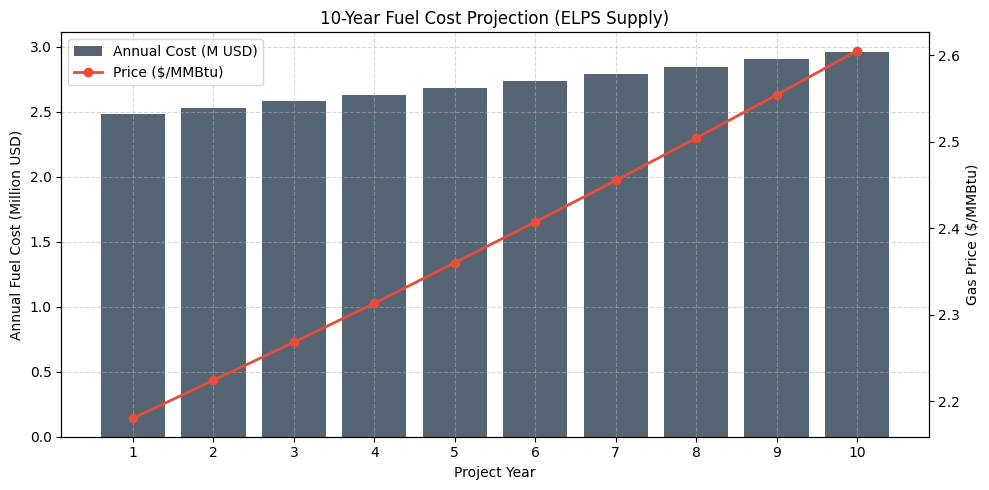

,Year,Price_USD_MMBtu,Annual_Cost_USD
0,1,2.180,2478344.0
1,2,2.224,2527911.0
2,3,2.268,2578469.0
3,4,2.313,2630039.0
4,5,2.360,2682639.0
5,6,2.407,2736292.0
6,7,2.455,2791018.0
7,8,2.504,2846838.0
8,9,2.554,2903775.0
9,10,2.605,2961851.0


In [3]:
years = np.arange(1, 11)
base_price = 2.18
escalation_rate = 0.02
prices = base_price * (1 + escalation_rate) ** (years - 1)

annual_mmbtu = fuel_input_mmbtu_day * 365
annual_costs = prices * annual_mmbtu

df_fuel = pd.DataFrame({
    'Year': years,
    'Price_USD_MMBtu': np.round(prices, 3),
    'Annual_Cost_USD': np.round(annual_costs, 0)
})

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(df_fuel['Year'], df_fuel['Annual_Cost_USD'] / 1_000_000, color='#2c3e50', alpha=0.8, label='Annual Cost (M USD)')
ax2.plot(df_fuel['Year'], df_fuel['Price_USD_MMBtu'], color='#e74c3c', marker='o', linewidth=2, label='Price ($/MMBtu)')

ax1.set_xlabel('Project Year')
ax1.set_ylabel('Annual Fuel Cost (Million USD)')
ax2.set_ylabel('Gas Price ($/MMBtu)')
ax1.set_title('10-Year Fuel Cost Projection (ELPS Supply)')
ax1.set_xticks(years)
ax1.grid(True, linestyle='--', alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/figures/03_fuel_cost_projection.png', dpi=300)
plt.show()

df_fuel


## 03.3 Supply Chain & Logistics

The Lekki FTZ location eliminates the need for expensive virtual pipeline (CNG/LNG trucking) logistics. The existing pipeline infrastructure provides a direct, low-cost supply channel.

**Pipeline Supply Agreement Structure (GSA):**
* **Supplier:** NGC (Nigerian Gas Company) / Private Franchisee
* **Take-or-Pay (ToP):** 80% MVC (Minimum Volume Commitment)
* **Delivery Pressure:** 40 - 45 barg
* **Gas Composition:** >95% Methane, Lean Gas (optimal for J624 knock-resistance)


In [4]:
# Save outputs for the next notebook
gas_data = {
    "daily_mmscf": float(gas_volume_mmscf_day),
    "annual_mmbtu": float(annual_mmbtu),
    "base_price_usd_mmbtu": float(base_price),
    "annual_escalation": float(escalation_rate)
}

with open('../outputs/03_gas_data.json', 'w') as f:
    json.dump(gas_data, f, indent=4)
print("Gas data exported successfully.")


Gas data exported successfully.
